# 线性回归

## 线性回归的实现

In [2]:
import random
import torch
from d2l import torch as d2l

In [3]:
def synthetic_data(w, b, num_example):
    """生成 y = Xw + b + 噪声"""
    X = torch.normal(0, 1, (num_example, len(w)))
    y = torch.matmul(X, w) + b  # torch.matmul() 矩阵乘法
    y += torch.normal(0, 0.01, y.shape)  # 加入噪声
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [4]:
features.shape

torch.Size([1000, 2])

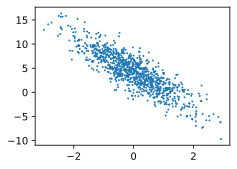

In [5]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1)

In [7]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 将样本打乱
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i:min(i+batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
    
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)

tensor([[-1.2419,  0.3381],
        [-2.1592,  0.7019],
        [-0.4308, -1.8446],
        [ 0.9906, -0.8842],
        [-1.2839, -2.0469],
        [-0.2967,  1.9679],
        [ 1.5725, -2.4978],
        [-0.7993, -1.7248],
        [-2.2786,  1.1073],
        [-0.2679,  2.5172]]) 
 tensor([[ 0.5609],
        [-2.5006],
        [ 9.6272],
        [ 9.1843],
        [ 8.5930],
        [-3.0896],
        [15.8292],
        [ 8.4755],
        [-4.1107],
        [-4.9033]])
tensor([[ 1.0629, -0.4620],
        [-0.6087, -0.6346],
        [-1.4235, -0.8319],
        [-0.8780,  0.5906],
        [ 0.7414,  0.1849],
        [ 0.0335,  0.3246],
        [-2.6725,  1.0728],
        [-0.4316,  0.0678],
        [ 0.2146,  0.4849],
        [ 0.4872, -1.3670]]) 
 tensor([[ 7.8940],
        [ 5.1424],
        [ 4.1748],
        [ 0.4384],
        [ 5.0600],
        [ 3.1665],
        [-4.8094],
        [ 3.0965],
        [ 2.9789],
        [ 9.8237]])
tensor([[ 0.3921,  0.4098],
        [-0.1997, -1.232

定义初始化模型参数

In [8]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
b

tensor([0.], requires_grad=True)

定义模型

In [9]:
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w)+b

定义损失函数

In [10]:
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape))**2 / 2

定义优化算法

In [11]:
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

训练过程

In [ ]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)

        l.sum().backward()  # 把 ∂loss/∂w 和 ∂loss/∂b 算出来，存到 w.grad 和 b.grad 里
        sgd([w, b], lr, batch_size)  # 使用梯度更新参数
    with torch.no_grad():  # 无需计算梯度
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.036244
epoch 2, loss 0.000132
epoch 3, loss 0.000053



# 线性回归的简洁实现

通过使用深度学习框架来简洁地实现线性回归模型生成数据集

In [14]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [15]:
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

next(iter(data_iter))

[tensor([[-0.3182,  0.9579],
         [ 1.5787,  0.3478],
         [-0.1796,  0.2046],
         [ 1.0396, -0.9486],
         [-1.4139, -0.5020],
         [ 0.2523, -1.9345],
         [-0.7685,  0.6831],
         [ 1.1837, -1.4478],
         [-1.2632,  0.0472],
         [-1.0042,  0.6754]]),
 tensor([[ 0.3177],
         [ 6.1819],
         [ 3.1281],
         [ 9.5251],
         [ 3.0885],
         [11.2885],
         [ 0.3320],
         [11.4926],
         [ 1.5318],
         [-0.0954]])]

使用框架的预定义好的层

In [ ]:
# 'nn'是神经网络的缩写
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))  # 输入维度为2,输出维度为1

初始化模型参数

In [18]:
net[0].weight.data.normal_(0, 0.01)  # 初始化w
net[0].bias.data.fill_(0)  # 初始化b

tensor([0.])

计算均方误差使用 MSELoss类

In [19]:
loss = nn.MSELoss()

实例化SGD实例

In [20]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

训练过程

In [ ]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()  # 更新数据w和b
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000181
epoch 2, loss 0.000108
epoch 3, loss 0.000107
